# генеративная модель: decoder-only трансформер

## imports & install

In [ ]:
import numpy as np
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import matplotlib.pyplot as plt

## data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = '/content/drive/MyDrive/pet_proj_recomendashki'
semantic_ids = np.load(f'{base_path}/data/semantic_ids.npy')
seq_df = pd.read_parquet(f'{base_path}/data/sequences_final')

print(semantic_ids.shape)
seq_df.head(2)

(26354, 3)


,user_id,item_seq,seq_len,item_seq_idx,train_hist,val,test,test_hist
0,AE2252DKW4XJIZP5QPFMQVJBVRTA,"[B0050SX4CI, B002ORTCAQ, B0090ECASW, B004OYV7Z...",11,"[16045, 2967, 10768, 11369, 22231, 13083, 2403...","[16045, 2967, 10768, 11369, 22231, 13083, 2403...",10554,21092,"[16045, 2967, 10768, 11369, 22231, 13083, 2403..."
1,AE22EOGVXOMYJ2QFJSYLWVBVAOAA,"[B008GEH9HO, B00CWV550U, B00J7N6C26, B07X6481D...",6,"[22999, 25270, 23345, 14220, 15609, 8219]","[22999, 25270, 23345, 14220]",15609,8219,"[22999, 25270, 23345, 14220, 15609]"


In [ ]:
def items_to_semantic(item_seq, semantic_ids):
    codes = semantic_ids[item_seq]
    return codes.flatten().tolist()

In [ ]:
seq_df['train_semantic'] = seq_df['train_hist'].apply(lambda x: items_to_semantic(np.array(x), semantic_ids))

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## dataset

In [ ]:
class SemanticSeqDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        return torch.tensor(seq, dtype=torch.long)

у последовательностей нефиксированная длина, не получится сразу преобразовать в тензор, нужно добавлять фиктивные значения в последовательности до длины максимальной последовательности в батче

само собой берем значение, которого нет в значениях кодов

In [ ]:
PAD_TOKEN = 256
vocab_size_per_level = 257

In [ ]:
def collate_fn(batch):
    padded = pad_sequence(batch, batch_first=True, padding_value=PAD_TOKEN)
    return padded

сразу определимся с длиной контекста

In [ ]:
seq_df['train_semantic_len'] = seq_df['train_semantic'].apply(len)

print(seq_df['train_semantic_len'].describe())
print()
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"{p} перцентиль: {seq_df['train_semantic_len'].quantile(p/100):.0f}")

count    95268.000000
mean        19.788890
std         23.705269
min          9.000000
25%          9.000000
50%         12.000000
75%         21.000000
max       1416.000000
Name: train_semantic_len, dtype: float64

50 перцентиль: 12
75 перцентиль: 21
90 перцентиль: 36
95 перцентиль: 51
99 перцентиль: 108
99.9 перцентиль: 264


выберем max_seq_len = 128, т.к. покрываем 99-й перцентиль и не упарываемся в покрытие выбросов среди длинн последовательностей, также при превышении max_seq_len будем округлять до 126 (42-х айтемов), а не 128, т.к. хотим получить последовательность токенов, которыми закодированны ЦЕЛЫЕ айтемы, а не их частички

In [ ]:
MAX_SEQ_LEN = 128
MAX_ITEMS = MAX_SEQ_LEN // 3

In [ ]:
def truncate_and_convert(item_id_list, semantic_ids, max_items=MAX_ITEMS):
    if len(item_id_list) > max_items:
        item_id_list = item_id_list[-max_items:]
    return items_to_semantic(item_id_list, semantic_ids)

In [ ]:
seq_df['train_semantic'] = seq_df['train_hist'].apply(lambda x: truncate_and_convert(x, semantic_ids))
seq_df['test_hist_semantic'] = seq_df['test_hist'].apply(lambda x: truncate_and_convert(x, semantic_ids))

In [ ]:
dataset = SemanticSeqDataset(seq_df['train_semantic'].tolist())
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

## архитектура

pos encoding проводим через RoPE

In [ ]:
class RotaryPositionEmbedding(nn.Module):
    def __init__(self, dim, max_seq_len=MAX_SEQ_LEN, base=10 ** 4):
        super().__init__()
        positions = torch.arange(max_seq_len)
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        angles = torch.outer(positions.float(), inv_freq)
        self.register_buffer('cos_cached', angles.cos())
        self.register_buffer('sin_cached', angles.sin())

    def forward(self, x):
        # batch, num_heads, seq_len, head_dim
        seq_len = x.shape[2]
        x1 = x[..., 0::2]
        x2 = x[..., 1::2]
        cos = self.cos_cached[:seq_len, :]
        sin = self.sin_cached[:seq_len, :]

        rotated_x1 = x1 * cos - x2 * sin
        rotated_x2 = x1 * sin + x2 * cos

        out = torch.stack([rotated_x1, rotated_x2], dim=-1)
        out = out.flatten(-2)

        return out

маскируем внимание (чтобы токены не видели будущее) и учитываем, что модель не должна обращать внимание на PAD-токены (они есть из-за последовательностей разной длины)

In [ ]:
def build_attention_mask(tokens, pad_token, num_heads):
    # batch, seq_len
    batch, seq_len = tokens.shape
    device = tokens.device

    causal_mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool, device=device), diagonal=1)
    causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)

    padding_mask = (tokens == pad_token)
    padding_mask = padding_mask.unsqueeze(1).unsqueeze(1)

    combined_mask = causal_mask | padding_mask

    return combined_mask

переходим к multi-head attention

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, max_seq_len=MAX_SEQ_LEN):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.head_agg = nn.Linear(d_model, d_model)
        self.rope = RotaryPositionEmbedding(dim=self.head_dim, max_seq_len=max_seq_len)

    def forward(self, x, attn_mask):
        # batch, seq_len, d_model
        batch, seq_len, _ = x.shape
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q_multi = Q.view(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        K_multi = K.view(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        V_multi = V.view(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)

        Q_rope = self.rope(Q_multi)
        K_rope = self.rope(K_multi)

        pre_softmax = Q_rope @ K_rope.transpose(-2, -1) / math.sqrt(self.head_dim)

        pre_softmax = pre_softmax.masked_fill(attn_mask, float('-inf'))

        atttention = torch.softmax(pre_softmax, dim=-1) @ V_multi
        atttention = atttention.transpose(1, 2).contiguous().view(batch, seq_len, self.d_model)

        out = self.head_agg(atttention)

        return out

опишем слой FFN

GELU - стандарт для трансформеров (вместо ReLU)

также добавим немного регуляризации через dropout

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or d_model * 4
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

опишем Decoder блок

нормализация - Pre-LN

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, max_seq_len=MAX_SEQ_LEN, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attention = MultiHeadAttention(d_model, n_heads, max_seq_len)
        self.dropout = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, dropout=dropout)

    def forward(self, x, attn_mask):
        atten_out = self.attention(self.norm1(x), attn_mask=attn_mask)
        x = x + self.dropout(atten_out)

        ffn_out = self.ffn(self.norm2(x))
        x = x + self.dropout(ffn_out)

        return x

также будем использовать разные таблицы эмбедингов на каждый индекс кода

In [ ]:
class MultiLevelEmbedding(nn.Module):
    def __init__(self, num_codes, n_levels, d_model, pad_token=None):
        super().__init__()
        self.n_levels = n_levels
        vocab_size = num_codes + 1
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, d_model) for i in range(n_levels)
        ])

    def forward(self, tokens):
        batch, seq_len = tokens.shape
        num_items = seq_len // self.n_levels

        tokens_reshaped = tokens.view(batch, num_items, self.n_levels)
        level_embeddings = []
        for level in range(self.n_levels):
            level_tokens = tokens_reshaped[:, :, level]
            level_embeddings.append(self.embeddings[level](level_tokens))

        out = torch.stack(level_embeddings, dim=2)
        out = out.view(batch, seq_len, -1)
        return out

и наконец собираем весь трансформер

у каждого уровня кода своя выходная голова. позиция `i` предсказывает токен `i + 1`, поэтому голова выбирается по уровню следующего токена

In [ ]:
class DecoderOnlyTransformer(nn.Module):
    def __init__(self, num_codes, n_levels, d_model, n_heads, n_layers,
                 max_seq_len=MAX_SEQ_LEN, pad_token=PAD_TOKEN, dropout=0):
        super().__init__()
        self.n_levels = n_levels
        self.pad_token = pad_token
        self.embeddings = MultiLevelEmbedding(num_codes, n_levels, d_model, pad_token)

        self.blocks = nn.ModuleList([
            DecoderBlock(d_model, n_heads, max_seq_len, dropout) for i in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)
        self.out_heads = nn.ModuleList([
            nn.Linear(d_model, num_codes + 1) for i in range(n_levels)
        ])

    def forward(self, tokens, attn_mask):
        x = self.embeddings(tokens)
        for block in self.blocks:
            x = block(x, attn_mask=attn_mask)
        x = self.final_norm(x)

        batch, seq_len, d_model = x.shape
        level_ids = (torch.arange(seq_len, device=x.device) + 1) % self.n_levels

        logits = torch.zeros(batch, seq_len, self.out_heads[0].out_features, device=x.device)
        for level in range(self.n_levels):
            mask = (level_ids == level)
            logits[:, mask, :] = self.out_heads[level](x[:, mask, :])

        return logits

## beam search

также опишем beam search, он позволит на инференсе получать результат значительно ближе к оптимальному, также нужен для получения нескольких валидных кандидатов (т.к. в контексе рекомендашки нам нужно > 1 результата в выдаче)

это значительно усложнит инференс (отправляем в модель батч из k элементов на генерацию), но модель относительно легка, поэтому ничего страшного нет

In [ ]:
def prepare_history_for_generation(history_tokens, max_seq_len, num_levels=3, reserve=3):
    max_history_len = max_seq_len - reserve
    max_history_items_len = (max_history_len // num_levels) * num_levels
    if len(history_tokens) > max_history_items_len:
        history_tokens = history_tokens[-max_history_items_len:]
    return history_tokens

In [ ]:
def beam_search_generate(model, history_tokens, trie, num_levels=3, k=10, pad_token=256, device='cpu'):
    model.eval()
    beams = [([], 0.0)]

    with torch.no_grad():
        for level in range(num_levels):
            batch_seqs = []
            real_positions = []
            for prefix, score in beams:
                full_seq = history_tokens + prefix
                remainder = len(full_seq) % 3
                real_pos = len(full_seq) - 1
                if remainder != 0:
                    full_seq = full_seq + [0] * (3 - remainder)
                batch_seqs.append(full_seq)
                real_positions.append(real_pos)

            max_len = max(len(s) for s in batch_seqs)
            padded_batch = [s + [pad_token] * (max_len - len(s)) for s in batch_seqs]
            input_tensor = torch.tensor(padded_batch, device=device)

            attn_mask = build_attention_mask(input_tensor, pad_token, model.blocks[0].attention.n_heads)
            logits = model(input_tensor, attn_mask=attn_mask)

            candidates = []
            for i, (prefix, score) in enumerate(beams):
                next_logits_i = logits[i, real_positions[i], :]

                valid_codes = trie.valid_next_codes(prefix)
                if len(valid_codes) == 0:
                    continue
                mask = torch.full_like(next_logits_i, float('-inf'))
                mask[valid_codes] = 0
                masked_logits = next_logits_i + mask
                log_probs = F.log_softmax(masked_logits, dim=-1)

                topk_log_probs, topk_codes = torch.topk(log_probs, k=min(k, len(valid_codes)))
                for code, log_p in zip(topk_codes.tolist(), topk_log_probs.tolist()):
                    candidates.append((prefix + [code], score + log_p))

            candidates.sort(key=lambda x: x[1], reverse=True)
            beams = candidates[:k]

    return beams

также модель не должна генерировать последовательности, которых нет в базе

решаем через Trie-индекс: на каждом шаге beam search разрешены только коды, которые продолжают существующий префикс

In [ ]:
class SemanticIDTrie:
    def __init__(self, all_semantic_ids):
        self.trie = {}
        self.id_to_item = {}
        for item_id, ids in enumerate(all_semantic_ids):
            ids_tuple = tuple(ids.tolist())
            self.id_to_item[ids_tuple] = item_id
            node = self.trie
            for code in ids_tuple:
                node = node.setdefault(code, {})

    def valid_next_codes(self, prefix):
        node = self.trie
        for code in prefix:
            node = node.get(code, {})
        return list(node.keys())

    def get_item_id(self, semantic_id_tuple):
        return self.id_to_item.get(semantic_id_tuple, None)

In [ ]:
trie = SemanticIDTrie(semantic_ids)

## metrics

Recall@k и NDCG@k по результатам beam search. ширина луча по умолчанию равна максимальному k

In [ ]:
def get_logits_at_position(model, seq, real_pos, device):
    remainder = len(seq) % 3
    padded_seq = seq + [0] * (3 - remainder) if remainder != 0 else seq
    seq_tensor = torch.tensor([padded_seq], device=device)
    attn_mask = build_attention_mask(seq_tensor, PAD_TOKEN, model.blocks[0].attention.n_heads)
    logits = model(seq_tensor, attn_mask=attn_mask)
    return logits[0, real_pos, :]


def compute_metrics(model, seq_df, trie, k_list=[5, 10, 50, 100], pad_token=PAD_TOKEN,
                    device='cpu', max_seq_len=MAX_SEQ_LEN, hist_col='test_hist_semantic',
                    target_col='test', beam_width=None):
    model.eval()
    recalls = {k: [] for k in k_list}
    ndcgs = {k: [] for k in k_list}
    max_k = max(k_list)

    for _, row in seq_df.iterrows():
        history = prepare_history_for_generation(row[hist_col], max_seq_len, num_levels=3, reserve=3)
        true_item_id = row[target_col]

        beams = beam_search_generate(model, history, trie, num_levels=3, k=beam_width or max_k,
                                     pad_token=pad_token, device=device)
        predicted_ids = [trie.get_item_id(tuple(seq)) for seq, score in beams]

        for k in k_list:
            top_k_preds = predicted_ids[:k]
            hit = true_item_id in top_k_preds
            recalls[k].append(1.0 if hit else 0.0)
            if hit:
                rank = top_k_preds.index(true_item_id) + 1
                ndcgs[k].append(1.0 / np.log2(rank + 1))
            else:
                ndcgs[k].append(0.0)

    results = {}
    for k in k_list:
        results[f'Recall@{k}'] = np.mean(recalls[k])
        results[f'NDCG@{k}'] = np.mean(ndcgs[k])
    return results

## обучение

обучаем на next-token prediction: вход — вся последовательность кодов, таргет — та же последовательность, сдвинутая на 1 токен (последняя позиция и паддинг в loss не участвуют). так второй код товара предсказывается при известном первом, а третий — при известных первых двух

т.к. используются 3 разные embedding-таблицы для каждого уровня кода, каждая из них получает только треть токенов, поэтому lr у эмбеддингов выше, чем у остальной модели

In [ ]:
checkpoint_dir = f'{base_path}/checkpoints'
config = {
    'num_codes': 256, 'n_levels': 3, 'd_model': 256, 'n_heads': 4, 'n_layers': 2,
    'max_seq_len': MAX_SEQ_LEN, 'pad_token': PAD_TOKEN, 'dropout': 0.1,
}

torch.manual_seed(42)
model = DecoderOnlyTransformer(**config).to(device)

embedding_params = list(model.embeddings.parameters())
other_params = [p for n, p in model.named_parameters() if not n.startswith('embeddings')]
optimizer = torch.optim.Adam([
    {'params': embedding_params, 'lr': 3e-3},
    {'params': other_params, 'lr': 1e-3},
])
hist = {'loss': []}

In [ ]:
max_epochs = 50
model.train()

for _ in range(max_epochs):
    epoch_loss = 0
    n_batch = 0

    for batch in dataloader:
        n_batch += 1
        batch = batch.to(device)

        input_seq = batch
        target_seq = F.pad(batch[:, 1:], (0, 1), value=PAD_TOKEN)
        attn_mask = build_attention_mask(input_seq, PAD_TOKEN, model.blocks[0].attention.n_heads)

        optimizer.zero_grad()
        logits = model(input_seq, attn_mask=attn_mask)
        loss = F.cross_entropy(
            logits.reshape(-1, logits.shape[-1]),
            target_seq.reshape(-1),
            ignore_index=PAD_TOKEN
        )
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / n_batch
    hist['loss'].append(avg_loss)
    global_epoch = len(hist['loss'])
    print(f"epoch {global_epoch} | loss: {round(avg_loss, 4)}")

    if global_epoch % 5 == 0:
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'hist': hist,
            'epoch': global_epoch,
            'config': config,
        }, f'{checkpoint_dir}/transformer_fixed_epoch{global_epoch}.pt')
        print(f"  -> сохранено: epoch {global_epoch}")

epoch 1 | loss: 3.5873
epoch 2 | loss: 3.0602
epoch 3 | loss: 2.9434
epoch 4 | loss: 2.8771
epoch 5 | loss: 2.8295
  -> сохранено: epoch 5
epoch 6 | loss: 2.7901
epoch 7 | loss: 2.758
epoch 8 | loss: 2.7296
epoch 9 | loss: 2.7048
epoch 10 | loss: 2.6816
  -> сохранено: epoch 10
epoch 11 | loss: 2.6605
epoch 12 | loss: 2.6423
epoch 13 | loss: 2.6241
epoch 14 | loss: 2.6086
epoch 15 | loss: 2.5923
  -> сохранено: epoch 15
epoch 16 | loss: 2.578
epoch 17 | loss: 2.5646
epoch 18 | loss: 2.5524
epoch 19 | loss: 2.5403
epoch 20 | loss: 2.5285
  -> сохранено: epoch 20
epoch 21 | loss: 2.5162
epoch 22 | loss: 2.5073
epoch 23 | loss: 2.4975
epoch 24 | loss: 2.4875
epoch 25 | loss: 2.479
  -> сохранено: epoch 25
epoch 26 | loss: 2.4699
epoch 27 | loss: 2.4616
epoch 28 | loss: 2.4545
epoch 29 | loss: 2.4461
epoch 30 | loss: 2.4388
  -> сохранено: epoch 30
epoch 31 | loss: 2.4318
epoch 32 | loss: 2.4251
epoch 33 | loss: 2.4185
epoch 34 | loss: 2.4118
epoch 35 | loss: 2.4066
  -> сохранено: epoch 3

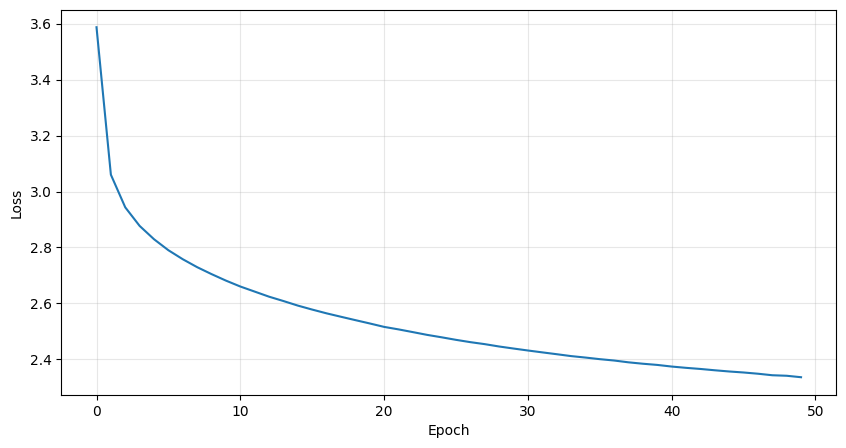

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(hist['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')
plt.grid(True, alpha=0.3)
plt.savefig(f'{checkpoint_dir}/training_loss_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

доучивание до 150 эпох с промежуточной оценкой каждые 10 эпох

**важно:** в этом прогоне функция метрик ещё игнорировала `hist_col` / `target_col`, поэтому числа `val Recall@10` в выводе ниже на самом деле посчитаны по тестовым целям тех же 1000 пользователей. по ним ничего не выбирается — эпоха выбрана в следующем разделе по корректной валидации на 5000 пользователях

In [ ]:
ck = torch.load(f'{checkpoint_dir}/transformer_fixed_epoch50.pt', map_location=device, weights_only=False)
model = DecoderOnlyTransformer(**ck['config']).to(device)
model.load_state_dict(ck['model_state_dict'])

embedding_params = list(model.embeddings.parameters())
other_params = [p for n, p in model.named_parameters() if not n.startswith('embeddings')]
optimizer = torch.optim.Adam([
    {'params': embedding_params, 'lr': 3e-3},
    {'params': other_params, 'lr': 1e-3},
])
optimizer.load_state_dict(ck['optimizer_state_dict'])
hist = ck['hist']
hist['val_epoch'], hist['val_recall10'] = [], []

val_df = seq_df.sample(n=1000, random_state=0)
max_epochs = 100
eval_every = 10

val_r10 = float(compute_metrics(model, val_df, trie, k_list=[10], device=device,
                                hist_col='train_semantic', target_col='val')['Recall@10'])
best_val, best_epoch = val_r10, 50
hist['val_epoch'].append(50)
hist['val_recall10'].append(val_r10)
print(f"epoch 50 | val Recall@10: {val_r10:.4f}")

for _ in range(max_epochs):
    model.train()
    epoch_loss = 0
    n_batch = 0

    for batch in dataloader:
        n_batch += 1
        batch = batch.to(device)
        input_seq = batch
        target_seq = F.pad(batch[:, 1:], (0, 1), value=PAD_TOKEN)
        attn_mask = build_attention_mask(input_seq, PAD_TOKEN, model.blocks[0].attention.n_heads)

        optimizer.zero_grad()
        logits = model(input_seq, attn_mask=attn_mask)
        loss = F.cross_entropy(
            logits.reshape(-1, logits.shape[-1]),
            target_seq.reshape(-1),
            ignore_index=PAD_TOKEN
        )
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / n_batch
    hist['loss'].append(avg_loss)
    global_epoch = len(hist['loss'])
    print(f"epoch {global_epoch} | loss: {round(avg_loss, 4)}")

    if global_epoch % eval_every == 0:
        val_r10 = float(compute_metrics(model, val_df, trie, k_list=[10], device=device,
                                        hist_col='train_semantic', target_col='val')['Recall@10'])
        hist['val_epoch'].append(global_epoch)
        hist['val_recall10'].append(val_r10)
        print(f"  -> val Recall@10: {val_r10:.4f}")

        torch.save({'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(),
                    'hist': hist, 'epoch': global_epoch, 'config': ck['config']},
                   f'{checkpoint_dir}/transformer_fixed_epoch{global_epoch}.pt')

        if val_r10 > best_val:
            best_val, best_epoch = val_r10, global_epoch

print(f"лучшая эпоха по val (1000 пользователей): {best_epoch}, Recall@10: {best_val:.4f}")

epoch 50 | val Recall@10: 0.0600
epoch 51 | loss: 2.3336
epoch 52 | loss: 2.3306
epoch 53 | loss: 2.3261
epoch 54 | loss: 2.3219
epoch 55 | loss: 2.3187
epoch 56 | loss: 2.3155
epoch 57 | loss: 2.313
epoch 58 | loss: 2.3091
epoch 59 | loss: 2.3068
epoch 60 | loss: 2.3032
  -> val Recall@10: 0.0510
epoch 61 | loss: 2.2998
epoch 62 | loss: 2.2974
epoch 63 | loss: 2.2952
epoch 64 | loss: 2.2926
epoch 65 | loss: 2.2893
epoch 66 | loss: 2.2869
epoch 67 | loss: 2.2844
epoch 68 | loss: 2.2814
epoch 69 | loss: 2.2787
epoch 70 | loss: 2.2767
  -> val Recall@10: 0.0550
epoch 71 | loss: 2.2738
epoch 72 | loss: 2.2716
epoch 73 | loss: 2.2703
epoch 74 | loss: 2.2671
epoch 75 | loss: 2.2655
epoch 76 | loss: 2.2628
epoch 77 | loss: 2.2608
epoch 78 | loss: 2.2584
epoch 79 | loss: 2.2563
epoch 80 | loss: 2.2545
  -> val Recall@10: 0.0540
epoch 81 | loss: 2.252
epoch 82 | loss: 2.2509
epoch 83 | loss: 2.2492
epoch 84 | loss: 2.2472
epoch 85 | loss: 2.2449
epoch 86 | loss: 2.2435
epoch 87 | loss: 2.2405


## model selection

валидация: история `train_hist` → цель `val`, 5000 пользователей. на эпохе 110 качество на валидации ниже, чем на 50, хотя train loss продолжал снижаться — модель начинает переобучаться. луча шириной 30 достаточно: качество как у 100 при втрое меньшем числе прогонов модели

In [ ]:
val_big = seq_df.sample(n=5000, random_state=1)
val_results = {}

for ep in sorted({50, best_epoch}):
    ck = torch.load(f'{checkpoint_dir}/transformer_fixed_epoch{ep}.pt', map_location=device, weights_only=False)
    model.load_state_dict(ck['model_state_dict'])
    val_results[ep] = compute_metrics(model, val_big, trie, k_list=[10, 100], device=device,
                                      hist_col='train_semantic', target_col='val', beam_width=30)
    print(ep, val_results[ep])

best_ep = max(val_results, key=lambda ep: val_results[ep]['Recall@10'])
ck = torch.load(f'{checkpoint_dir}/transformer_fixed_epoch{best_ep}.pt', map_location=device, weights_only=False)
model.load_state_dict(ck['model_state_dict'])
print('выбрана эпоха:', best_ep)

50 {'Recall@10': np.float64(0.0682), 'NDCG@10': np.float64(0.03737748694419453), 'Recall@100': np.float64(0.2112), 'NDCG@100': np.float64(0.06525002448237485)}
110 {'Recall@10': np.float64(0.0614), 'NDCG@10': np.float64(0.03376493660873113), 'Recall@100': np.float64(0.1992), 'NDCG@100': np.float64(0.06083819946884048)}
выбрана эпоха: 50


In [ ]:
beam_results = {}
for bw in [10, 30, 100]:
    beam_results[bw] = compute_metrics(model, val_big, trie, k_list=[10], device=device,
                                       hist_col='train_semantic', target_col='val', beam_width=bw)
    print(bw, beam_results[bw])

10 {'Recall@10': np.float64(0.064), 'NDCG@10': np.float64(0.0358282213925239)}
30 {'Recall@10': np.float64(0.0684), 'NDCG@10': np.float64(0.03744585992964525)}
100 {'Recall@10': np.float64(0.0682), 'NDCG@10': np.float64(0.03737748694419453)}


## тест

история `test_hist` → цель `test`, 1000 пользователей (`random_state=42`, та же выборка, что у DSSM). считается один раз, для эпохи, выбранной по валидации

In [ ]:
eval_df = seq_df.sample(n=1000, random_state=42)
results_final = compute_metrics(model, eval_df, trie, device=device)
print('эпоха', best_ep, results_final)

эпоха 50 {'Recall@5': np.float64(0.04), 'NDCG@5': np.float64(0.025758297478401034), 'Recall@10': np.float64(0.062), 'NDCG@10': np.float64(0.032652313953801214), 'Recall@50': np.float64(0.126), 'NDCG@50': np.float64(0.046310031517512486), 'Recall@100': np.float64(0.185), 'NDCG@100': np.float64(0.05595091031973602)}


бейзлайн MostPop на той же выборке: всем рекомендуем самые популярные товары

In [ ]:
pop_counter = Counter(int(i) for h in seq_df['test_hist'] for i in h)
top_items = [i for i, _ in pop_counter.most_common(100)]

pop_results = {}
for k in [5, 10, 50, 100]:
    top_k = top_items[:k]
    hits = [int(row['test']) in top_k for _, row in eval_df.iterrows()]
    ndcg = [1 / np.log2(top_k.index(int(row['test'])) + 2) if int(row['test']) in top_k else 0.0 for _, row in eval_df.iterrows()]
    pop_results[f'Recall@{k}'] = np.mean(hits)
    pop_results[f'NDCG@{k}'] = np.mean(ndcg)
print(pop_results)

{'Recall@5': np.float64(0.007), 'NDCG@5': np.float64(0.004879135676952785), 'Recall@10': np.float64(0.021), 'NDCG@10': np.float64(0.009462944658642445), 'Recall@50': np.float64(0.058), 'NDCG@50': np.float64(0.017304944214579492), 'Recall@100': np.float64(0.089), 'NDCG@100': np.float64(0.022239281833459905)}


### ошибки модели

ранг правильного кода на каждом уровне при известном правильном префиксе (teacher forcing): сначала среди всех 257 кодов, затем только среди допустимых продолжений по Trie — именно из них выбирает beam search

In [ ]:
ranks = [[], [], []]
model.eval()
with torch.no_grad():
    for _, row in eval_df.iterrows():
        history = prepare_history_for_generation(row['test_hist_semantic'], MAX_SEQ_LEN, num_levels=3, reserve=3)
        true_codes = [int(c) for c in semantic_ids[row['test']]]
        for level in range(3):
            seq = history + true_codes[:level]
            logits = get_logits_at_position(model, seq, len(seq) - 1, device)
            ranks[level].append((logits > logits[true_codes[level]]).sum().item() + 1)

for level in range(3):
    print(f"уровень {level}: средний ранг {np.mean(ranks[level]):.1f} / 257 | топ-10: {np.mean([r <= 10 for r in ranks[level]]) * 100:.1f}%")
all3 = np.mean([a <= 10 and b <= 10 and c <= 10 for a, b, c in zip(*ranks)])
print(f"все три в топ-10: {all3 * 100:.1f}%")

уровень 0: средний ранг 59.2 / 257 | топ-10: 27.0%
уровень 1: средний ранг 16.6 / 257 | топ-10: 59.2%
уровень 2: средний ранг 1.5 / 257 | топ-10: 99.4%
все три в топ-10: 16.6%


In [ ]:
ranks = [[], [], []]
rand = [[], [], []]
n_valid = [[], [], []]
model.eval()
with torch.no_grad():
    for _, row in eval_df.iterrows():
        history = prepare_history_for_generation(row['test_hist_semantic'], MAX_SEQ_LEN, num_levels=3, reserve=3)
        true_codes = [int(c) for c in semantic_ids[row['test']]]
        for level in range(3):
            prefix = true_codes[:level]
            valid = trie.valid_next_codes(prefix)
            seq = history + prefix
            logits = get_logits_at_position(model, seq, len(seq) - 1, device)
            ranks[level].append((logits[valid] > logits[true_codes[level]]).sum().item() + 1)
            rand[level].append((len(valid) + 1) / 2)
            n_valid[level].append(len(valid))

for level in range(3):
    r = np.array(ranks[level])
    print(f"уровень {level}: кандидатов в среднем {np.round(np.mean(n_valid[level]), 1)} | ранг {np.round(r.mean(), 2)} | случайный {np.round(np.mean(rand[level]), 2)} | топ-1: {np.round(np.mean(r == 1) * 100, 1)}%")

уровень 0: кандидатов в среднем 256.0 | ранг 59.18 | случайный 128.5 | топ-1: 4.1%
уровень 1: кандидатов в среднем 71.8 | ранг 14.68 | случайный 36.38 | топ-1: 18.8%
уровень 2: кандидатов в среднем 2.6 | ранг 1.29 | случайный 1.78 | топ-1: 81.8%


часть тестовых товаров делит семантический ID с другим товаром, и Trie всегда возвращает другой — такие цели модель не может угадать никогда

In [ ]:
unreachable = np.mean([trie.get_item_id(tuple(int(c) for c in semantic_ids[int(t)])) != int(t) for t in eval_df['test']])
print(f"недостижимых тестовых целей: {unreachable * 100:.1f}%")

недостижимых тестовых целей: 4.5%
